# Exercice 1

In [52]:
import pandas as pd

In [53]:
data_titanic = pd.read_csv('/content/train.csv')
print(data_titanic.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [54]:
print(data_titanic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [55]:
print(data_titanic.duplicated().sum())

0


In [56]:
data_titanic = data_titanic.drop_duplicates()

In [57]:
print(data_titanic.duplicated().sum())

0


# Exercice 2

In [58]:
print(data_titanic.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Nous avons des données manquantes aux colonnes : Age , Cabin, Embarked

In [59]:
from sklearn.impute import SimpleImputer

data_titanic_cleaned = data_titanic.dropna(subset=['Embarked']).copy()


data_titanic_cleaned.loc[:, 'Cabin'] = \
data_titanic_cleaned['Cabin'].fillna('nome')


data_titanic_cleaned.loc[:, 'Age'] = \
imputer.fit_transform(data_titanic_cleaned[['Age']])

print(data_titanic_cleaned.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


# Exercice 3

In [60]:
data_titanic_cleaned.loc[:, 'FamilySize'] = data_titanic_cleaned['SibSp'] + data_titanic_cleaned['Parch'] + 1


data_titanic_cleaned.loc[:, 'Title'] = data_titanic_cleaned['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print(data_titanic_cleaned[['Name', 'SibSp', 'Parch', 'FamilySize', 'Title']].head())

                                                Name  SibSp  Parch  \
0                            Braund, Mr. Owen Harris      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...      1      0   
2                             Heikkinen, Miss. Laina      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)      1      0   
4                           Allen, Mr. William Henry      0      0   

   FamilySize Title  
0           2    Mr  
1           2   Mrs  
2           1  Miss  
3           2   Mrs  
4           1    Mr  


In [61]:
categorical_vars = data_titanic_cleaned.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Variables catégoriques détectées sont :")
print(categorical_vars)

Variables catégoriques détectées sont :
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Title']


Les variables 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Title' sont des Variables nominales (Variables sans ordre logique)

In [62]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['Name', 'Sex', 'Ticket']
le = LabelEncoder()

for col in label_cols:
    data_titanic_cleaned[col] = le.fit_transform(data_titanic_cleaned[col].astype(str))


print("Aperçu de data_titanic_cleaned après encodage :")
display(data_titanic_cleaned.head())

Aperçu de data_titanic_cleaned après encodage :


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Title
0,1,0,3,108,1,22.0,1,0,522,7.2500,nome,S,2,Mr
1,2,1,1,190,0,38.0,1,0,595,71.2833,C85,C,2,Mrs
2,3,1,3,353,0,26.0,0,0,668,7.9250,nome,S,1,Miss
3,4,1,1,272,0,35.0,1,0,48,53.1000,C123,S,2,Mrs
4,5,0,3,15,1,35.0,0,0,471,8.0500,nome,S,1,Mr


# Exercice 4

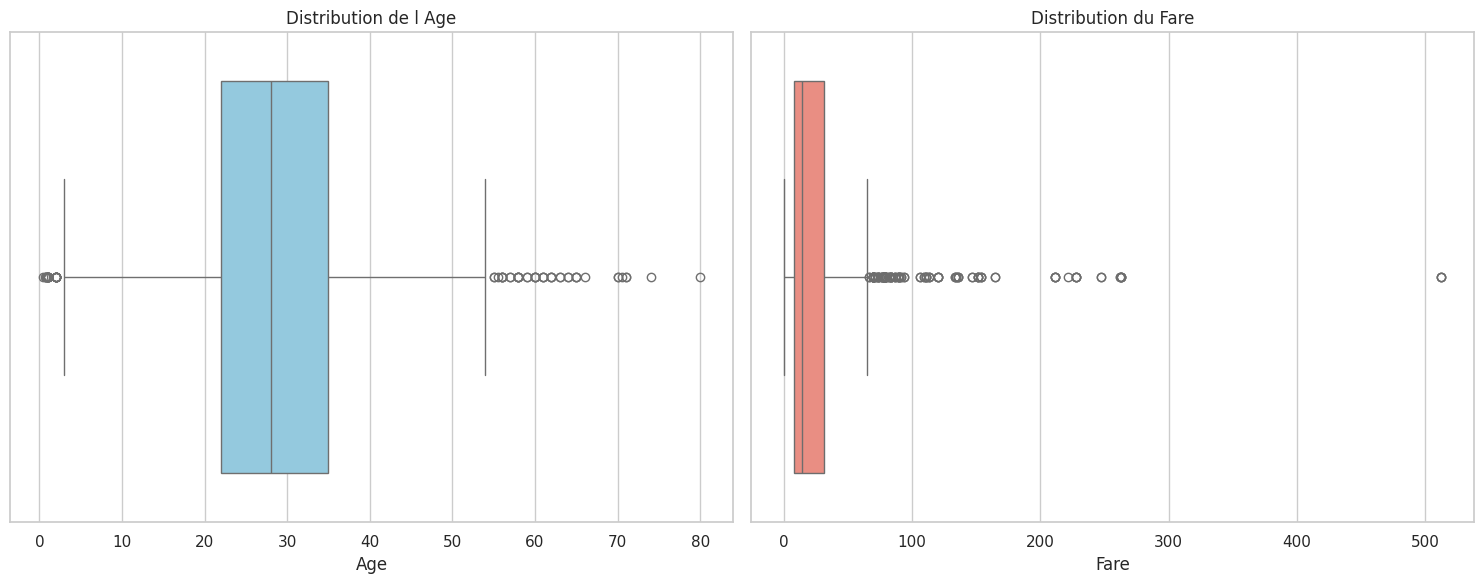

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(ax=axes[0], x=data_titanic_cleaned['Age'], color='skyblue')
axes[0].set_title('Distribution de l Age')
axes[0].set_xlabel('Age')


sns.boxplot(ax=axes[1], x=data_titanic_cleaned['Fare'], color='salmon')
axes[1].set_title('Distribution du Fare')
axes[1].set_xlabel('Fare')

plt.tight_layout()
plt.show()

In [64]:
import numpy as np

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

def detect_outliers_zscore_manual(data, column, threshold=3):
    mean = data[column].mean()
    std = data[column].std()
    z_scores = (data[column] - mean) / std
    outliers = data[np.abs(z_scores) > threshold]
    return outliers


outliers_age_iqr, lb_age, ub_age = detect_outliers_iqr(data_titanic_cleaned, 'Age')
outliers_age_z = detect_outliers_zscore_manual(data_titanic_cleaned, 'Age')


outliers_fare_iqr, lb_fare, ub_fare = detect_outliers_iqr(data_titanic_cleaned, 'Fare')
outliers_fare_z = detect_outliers_zscore_manual(data_titanic_cleaned, 'Fare')

print(f"Analyse Age")
print(f"Outliers (IQR): {len(outliers_age_iqr)} | Bornes: [{lb_age:.2f}, {ub_age:.2f}]")
print(f"Outliers (Z-score): {len(outliers_age_z)}")

print(f"\nAnalyse Fare")
print(f"Outliers (IQR): {len(outliers_fare_iqr)} | Bornes: [{lb_fare:.2f}, {ub_fare:.2f}]")
print(f"Outliers (Z-score): {len(outliers_fare_z)}")

Analyse Age
Outliers (IQR): 65 | Bornes: [2.50, 54.50]
Outliers (Z-score): 7

Analyse Fare
Outliers (IQR): 114 | Bornes: [-26.76, 65.66]
Outliers (Z-score): 20


In [65]:
data_capping1 = data_titanic_cleaned.copy()

for col in ['Age', 'Fare']:
    upper_limit = data_capping1[col].quantile(0.98)
    data_capping1[col] = np.where(data_capping1[col] > upper_limit, upper_limit, data_capping1[col])


data_log = data_titanic_cleaned.copy()
data_log['Fare_log'] = np.log1p(data_log['Fare'])


data_removal = data_titanic_cleaned[
    (data_titanic_cleaned['Age'] >= lb_age) & (data_titanic_cleaned['Age'] <= ub_age) &
    (data_titanic_cleaned['Fare'] >= lb_fare) & (data_titanic_cleaned['Fare'] <= ub_fare)
].copy()

print(f"Taille originale : {len(data_titanic_cleaned)}")
print(f"Taille après suppression des outliers : {len(data_removal)}")
print("\nAperçu du Capping (Age & Fare) :")
display(data_capping1[['Age', 'Fare']].describe().loc[['max', '98%'] if '98%' in data_capping1[['Age', 'Fare']].describe().index else ['max']])

Taille originale : 889
Taille après suppression des outliers : 721

Aperçu du Capping (Age & Fare) :


,Age,Fare
max,61.24,211.3375


In [66]:
data_capping2 = data_titanic_cleaned.copy()

for col in ['Age', 'Fare']:
    upper_limit = data_capping2[col].quantile(0.99)
    data_capping2[col] = np.where(data_capping2[col] > upper_limit, upper_limit, data_capping2[col])


data_log = data_titanic_cleaned.copy()
data_log['Fare_log'] = np.log1p(data_log['Fare'])


data_removal = data_titanic_cleaned[
    (data_titanic_cleaned['Age'] >= lb_age) & (data_titanic_cleaned['Age'] <= ub_age) &
    (data_titanic_cleaned['Fare'] >= lb_fare) & (data_titanic_cleaned['Fare'] <= ub_fare)
].copy()

print(f"Taille originale : {len(data_titanic_cleaned)}")
print(f"Taille après suppression des outliers : {len(data_removal)}")
print("\nAperçu du Capping (Age & Fare) :")
display(data_capping2[['Age', 'Fare']].describe().loc[['max', '98%'] if '98%' in data_capping2[['Age', 'Fare']].describe().index else ['max']])

Taille originale : 889
Taille après suppression des outliers : 721

Aperçu du Capping (Age & Fare) :


,Age,Fare
max,65.0,249.303304


In [67]:
print("Statistiques descriptives comparatives Fare :")
comparison_fare = pd.DataFrame({
    'Original': data_titanic_cleaned['Fare'].describe(),
    'Capped (0.98)': data_capping1['Fare'].describe(),
    'Capped (0.99)': data_capping2['Fare'].describe()
})
display(comparison_fare)

print("\nStatistiques descriptives comparatives Age :")
comparison_age = pd.DataFrame({
    'Original': data_titanic_cleaned['Age'].describe(),
    'Capped (0.98)': data_capping1['Age'].describe(),
    'Capped (0.99)': data_capping2['Age'].describe()
})
display(comparison_age)

Statistiques descriptives comparatives Fare :


,Original,Capped (0.98),Capped (0.99)
count,889.000000,889.000000,889.000000
mean,32.096681,30.567524,31.118044
std,49.697504,39.881074,42.524308
min,0.000000,0.000000,0.000000
25%,7.895800,7.895800,7.895800
50%,14.454200,14.454200,14.454200
75%,31.000000,31.000000,31.000000
max,512.329200,211.337500,249.303304



Statistiques descriptives comparatives Age :


,Original,Capped (0.98),Capped (0.99)
count,889.000000,889.000000,889.000000
mean,29.315152,29.196839,29.256097
std,12.984932,12.643921,12.801106
min,0.420000,0.420000,0.420000
25%,22.000000,22.000000,22.000000
50%,28.000000,28.000000,28.000000
75%,35.000000,35.000000,35.000000
max,80.000000,61.240000,65.000000


# Exercice 5

In [68]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


std_scaler = StandardScaler()
data_titanic_cleaned.loc[:, 'Fare_normalized'] = std_scaler.fit_transform(data_titanic_cleaned[['Fare']])


mm_scaler = MinMaxScaler()
data_titanic_cleaned.loc[:, 'Age_normalized'] = mm_scaler.fit_transform(data_titanic_cleaned[['Age']])

print("Aperçu de data_titanic_cleaned après mise à l'échelle (Scaling) :")
display(data_titanic_cleaned[['Age', 'Age_normalized', 'Fare', 'Fare_normalized']].head())

Aperçu de data_titanic_cleaned après mise à l'échelle (Scaling) :


,Age,Age_normalized,Fare,Fare_normalized
0,22.0,0.271174,7.2500,-0.500240
1,38.0,0.472229,71.2833,0.788947
2,26.0,0.321438,7.9250,-0.486650
3,35.0,0.434531,53.1000,0.422861
4,35.0,0.434531,8.0500,-0.484133


In [69]:
print(data_titanic_cleaned)

     PassengerId  Survived  Pclass  Name  Sex   Age  SibSp  Parch  Ticket  \
0              1         0       3   108    1  22.0      1      0     522   
1              2         1       1   190    0  38.0      1      0     595   
2              3         1       3   353    0  26.0      0      0     668   
3              4         1       1   272    0  35.0      1      0      48   
4              5         0       3    15    1  35.0      0      0     471   
..           ...       ...     ...   ...  ...   ...    ...    ...     ...   
886          887         0       2   547    1  27.0      0      0     100   
887          888         1       1   303    0  19.0      0      0      14   
888          889         0       3   412    0  28.0      1      2     674   
889          890         1       1    81    1  26.0      0      0       8   
890          891         0       3   220    1  32.0      0      0     465   

        Fare Cabin Embarked  FamilySize Title  Fare_normalized  Age_normali

# Exercice 6

Les colonnes catégoriques restantes sont : 'Cabin','Embarked', 'Title'

elles sont de types de nominale. nous pouvons appliqué l'encodage One-Hot Encoding

In [70]:
cols_to_ohe = ['Cabin', 'Embarked', 'Title']

data_titanic_cleaned = pd.get_dummies(data_titanic_cleaned, columns=cols_to_ohe, dtype=int)

print("Aperçu de data_titanic_cleaned après One-Hot Encoding :")
display(data_titanic_cleaned.head())

Aperçu de data_titanic_cleaned après One-Hot Encoding :


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir
0,1,0,3,108,1,22.0,1,0,522,7.2500,...,0,0,0,0,0,1,0,0,0,0
1,2,1,1,190,0,38.0,1,0,595,71.2833,...,0,0,0,0,0,0,1,0,0,0
2,3,1,3,353,0,26.0,0,0,668,7.9250,...,0,0,1,0,0,0,0,0,0,0
3,4,1,1,272,0,35.0,1,0,48,53.1000,...,0,0,0,0,0,0,1,0,0,0
4,5,0,3,15,1,35.0,0,0,471,8.0500,...,0,0,0,0,0,1,0,0,0,0


# Exercice 7

In [76]:

bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']


data_titanic_cleaned['AgeGroup'] = pd.cut(data_titanic_cleaned['Age'], bins=bins, labels=labels)

print("Aperçu de data_titanic_cleaned après création de AgeGroup :")
display(data_titanic_cleaned[['Age', 'AgeGroup']].head())

data_titanic_cleaned = pd.get_dummies(data_titanic_cleaned, columns=['AgeGroup'], dtype=int)

print("\nAperçu des nouvelles colonnes AgeGroup encodées :")
display(data_titanic_cleaned.filter(like='AgeGroup').head(15))

Aperçu de data_titanic_cleaned après création de AgeGroup :


,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult



Aperçu des nouvelles colonnes AgeGroup encodées :


,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior
0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0
1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0
2,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0
3,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0
4,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0
5,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0
6,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0
7,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0
8,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0
9,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0
